<a href="https://colab.research.google.com/github/nimraa9090/AI-projects/blob/main/cartpoledqn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y gym
!pip install gymnasium[classic_control] stable-baselines3 shimmy "numpy<2.0.0"

Found existing installation: gym 0.25.2
Uninstalling gym-0.25.2:
  Successfully uninstalled gym-0.25.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, which is not installed.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires

In [ ]:
import gymnasium as gym
from stable_baselines3 import DQN

# 1. Initialize the Environment
env = gym.make("CartPole-v1", render_mode=None)

# 2. Initialize the Model (DQN)
# MlpPolicy means a standard Multi-Layer Perceptron (Neural Network)
model = DQN("MlpPolicy", env, verbose=1)

# 3. Train the Agent
print("Training the agent...")
model.learn(total_timesteps=20000)
print("Training complete!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training the agent...
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 31.5     |
|    ep_rew_mean      | 31.5     |
|    exploration_rate | 0.94     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 570      |
|    time_elapsed     | 0        |
|    total_timesteps  | 126      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.535    |
|    n_updates        | 6        |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 33.9     |
|    ep_rew_mean      | 33.9     |
|    exploration_rate | 0.871    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 731      |
|    time_elapsed     | 0        |
|    total_timesteps  | 271      |
| train/ 

In [ ]:
import gymnasium as gym

# Create an environment for testing
test_env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, info = test_env.reset()

# Check if the 'model' has been defined. If not, inform the user.
if 'model' not in locals() and 'model' not in globals():
    print("Error: The 'model' has not been defined. This usually happens if the training cell (cell lIt5CphNuoFv) was not executed, or if the kernel was restarted (e.g., after a crash).")
    print("Please go back and run the cell where the model is initialized and trained before attempting to test it.")
else:
    for i in range(500):
        # Predict the best action from the neural network
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)

        if terminated or truncated:
            break

test_env.close()

In [ ]:
import gymnasium as gym

# Create a new environment for visualization
# Using 'CartPole-v1' as it was used for training
env_viz = gym.make("CartPole-v1", render_mode="rgb_array")

# Reset the environment and get the initial observation
obs, info = env_viz.reset()

frames = []
# Run for a maximum of 500 steps or until the episode ends
for _ in range(500):
    # Render the current frame
    frames.append(env_viz.render())

    # Predict the action using the trained model
    action, _states = model.predict(obs, deterministic=True)

    # Take the action in the environment
    obs, reward, terminated, truncated, info = env_viz.step(action)

    # Check if the episode is terminated or truncated
    if terminated or truncated:
        break

env_viz.close()
print(f"Collected {len(frames)} frames for visualization.")

Collected 9 frames for visualization.


In [ ]:
# Install libraries for GIF generation
!pip install imageio imageio-ffmpeg

In [ ]:
import os

# Define a path to save the model
model_save_path = "dqn_cartpole_model"

# Save the model
model.save(model_save_path)

print(f"Model saved to {model_save_path}.zip")

# Check if the file exists
if os.path.exists(model_save_path + ".zip"):
    print("Model file successfully created.")
else:
    print("Error: Model file not found after saving.")

Model saved to dqn_cartpole_model.zip
Model file successfully created.


In [ ]:
from stable_baselines3 import DQN

# Create a new environment instance (important for loading the model correctly)
env_loaded = gym.make("CartPole-v1", render_mode="rgb_array")

# Load the model from the saved path
# Make sure the environment used for loading matches the one used for training
loaded_model = DQN.load(model_save_path, env=env_loaded)

print("Model loaded successfully!")

# You can now test the loaded model
obs_loaded, info_loaded = env_loaded.reset()
print("Testing loaded model for 5 steps:")
for i in range(5):
    action_loaded, _states_loaded = loaded_model.predict(obs_loaded, deterministic=True)
    obs_loaded, reward_loaded, terminated_loaded, truncated_loaded, info_loaded = env_loaded.step(action_loaded)
    print(f"Step {i+1}: Action={action_loaded}, Reward={reward_loaded}, Terminated={terminated_loaded}")
    if terminated_loaded or truncated_loaded:
        break
env_loaded.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Model loaded successfully!
Testing loaded model for 5 steps:
Step 1: Action=1, Reward=1.0, Terminated=False
Step 2: Action=1, Reward=1.0, Terminated=False
Step 3: Action=1, Reward=1.0, Terminated=False
Step 4: Action=1, Reward=1.0, Terminated=False
Step 5: Action=1, Reward=1.0, Terminated=False


GIF saved to cartpole_agent.gif


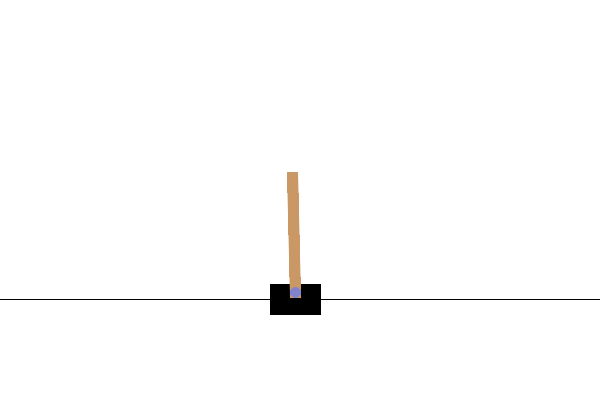

In [ ]:
import imageio

# Create a GIF from the collected frames
gif_path = "cartpole_agent.gif"
imageio.mimsave(gif_path, frames, fps=30) # fps can be adjusted

print(f"GIF saved to {gif_path}")

# Display the GIF (optional, but good for interactive viewing in Colab)
from IPython.display import Image
Image(open(gif_path,'rb').read())